# 

In [2]:
import seaborn as sns
import random

In [5]:
df=sns.load_dataset('titanic')

In [6]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [13]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [17]:
df['new_deck']=df['deck'].fillna(df['deck'].mean())

TypeError: 'Categorical' with dtype category does not support reduction 'mean'

In [21]:
df.dropna().shape

(182, 15)

In [24]:
df['new_age']=df['age'].fillna(df['age'].mean())
df[['new_age','age']]

,new_age,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


In [25]:
#Mean imputation works well when we have normally distributed data

<Axes: xlabel='age', ylabel='Count'>

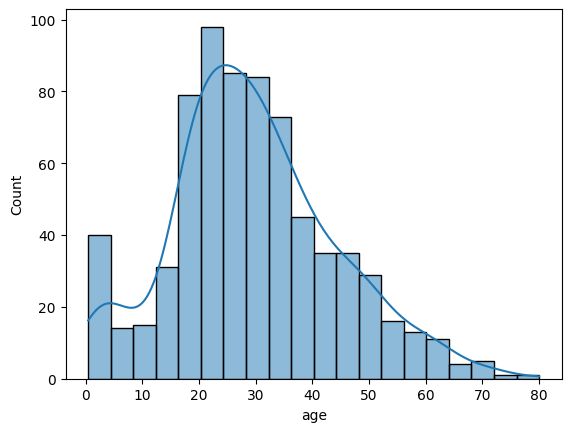

In [37]:
import seaborn as sns
sns.histplot(df['age'],kde=True)


In [46]:
df['rand_age']=df['age'].fillna(random.randint(40,80))
df[['age','rand_age']]

,age,rand_age
0,22.0,22.0
1,38.0,38.0
2,26.0,26.0
3,35.0,35.0
4,35.0,35.0
...,...,...
886,27.0,27.0
887,19.0,19.0
888,NaN,50.0
889,26.0,26.0


In [43]:
df['age'].max()

np.float64(80.0)

In [42]:
df['age'].min()

np.float64(0.42)

In [47]:
#SMOTE

In [48]:
from sklearn.datasets import make_classification

In [89]:
x,y=make_classification(n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1,weights=[0.9],random_state=12)

In [90]:
import pandas as pd
import numpy as np
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df=pd.concat([df1,df2],axis=1)
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [91]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [53]:
import matplotlib.pyplot as plt

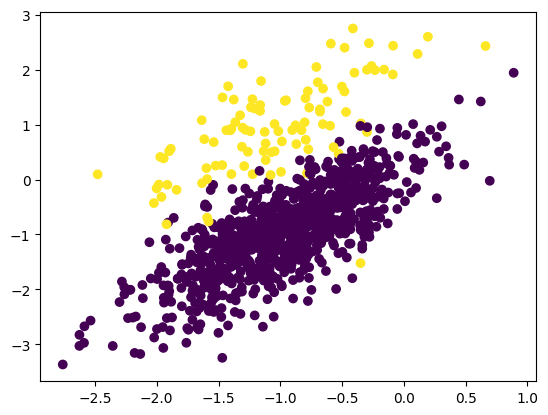

In [92]:
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])

In [62]:
!pip install imblearn

In [95]:
from imblearn.over_sampling import SMOTE

In [94]:
#transfom the dataset
oversample=SMOTE(k_neighbors=2, random_state=42)
x,y=oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

In [96]:
x.shape


(1800, 2)

In [97]:
y.shape

(1800,)

In [78]:
len(y)

1994

In [98]:
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
oversample_df=pd.concat([df1,df2],axis=1)

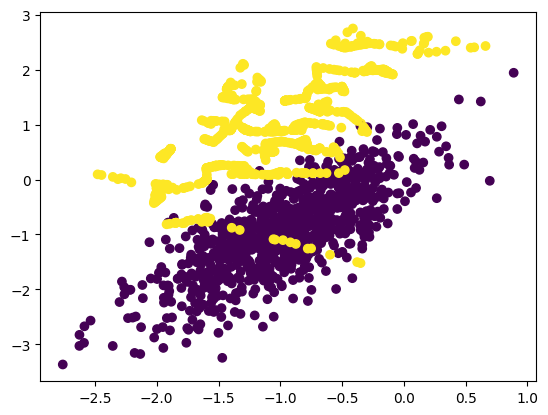

In [99]:
plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['target'])

In [ ]:
import pandas as pd 
from imblearn.over_sampling import SMOTE
df1=pd.DataFrame(x=['f1','f2']
df2=pd.DataFrame(y=['target'])
pd.concat([df1,df2],axis=1)



In [ ]:
#OHE

In [22]:
import seaborn as sns
import pandas as pd
df=sns.load_dataset('tips')
df1=df[['sex']]
print(df)


     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


In [24]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
encoder=OneHotEncoder() #instance
encoded=encoder.fit_transform(df[['sex']]).toarray()
encoded_df=pd.DataFrame(encoded,columns=encoder.get_feature_names_out())
new_df=pd.concat([df1,encoded_df],axis=1)
new_df.head()

,sex,sex_Female,sex_Male
0,Female,1.0,0.0
1,Male,0.0,1.0
2,Male,0.0,1.0
3,Male,0.0,1.0
4,Female,1.0,0.0


In [4]:
import seaborn as sns
import pandas as pd
df=sns.load_dataset('penguins')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [5]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [8]:
df['body_mass_g_mean']=df['body_mass_g'].fillna(df['body_mass_g'].mean())

In [15]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
body_mass_g_mean      0
dtype: int64

<Axes: xlabel='body_mass_g', ylabel='Count'>

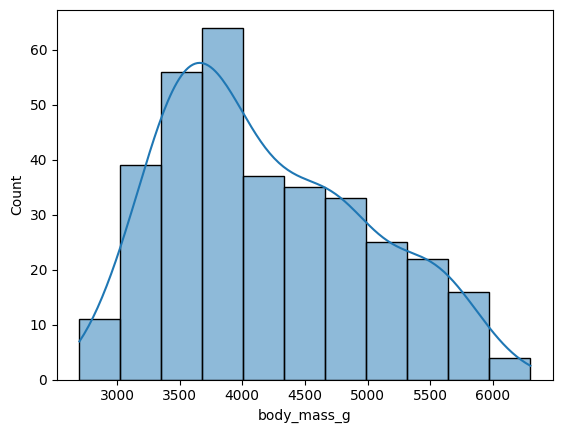

In [19]:
sns.histplot(df['body_mass_g'],kde=True)

In [13]:
df1=df[['body_mass_g']]
df2=df[['body_mass_g_mean']]
df3=pd.concat([df1,df2],axis=1)
df3.head()

,body_mass_g,body_mass_g_mean
0,3750.0,3750.000000
1,3800.0,3800.000000
2,3250.0,3250.000000
3,NaN,4201.754386
4,3450.0,3450.000000


In [20]:
sns.load_dataset("tips")

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
